# Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

np.random.seed(42)


# Kaggle Dataset

In [2]:
# Kaggle: https://www.kaggle.com/datasets/uciml/iris

try:
    import kagglehub
    path = kagglehub.dataset_download("uciml/iris")
    df = pd.read_csv(os.path.join(path, "Iris.csv"))
except Exception:
    df = pd.read_csv("Iris.csv")

df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-Setosa
1,2,4.9,3.0,1.4,0.2,Iris-Setosa
2,3,4.7,3.2,1.3,0.2,Iris-Setosa
3,4,4.6,3.1,1.5,0.2,Iris-Setosa
4,5,5.0,3.6,1.4,0.2,Iris-Setosa


# Dataset Shape

In [3]:
df.shape

(150, 6)

# Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# Preprocessing

In [5]:
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

y = (df["Species"] != "Iris-Setosa").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Classes:", sorted(y.unique()))


Training samples: 120
Testing samples: 30
Classes: [np.int64(0), np.int64(1)]


# Random Forest Classification

In [6]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", round(rf_accuracy, 4))
print()
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Iris-Setosa", "Non-Setosa"]
))

rf_cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:")
print(rf_cm)


Accuracy: 1.0

              precision    recall  f1-score   support

 Iris-Setosa       1.00      1.00      1.00        10
  Non-Setosa       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0]
 [ 0 20]]


# Random Forest Confusion Matrix

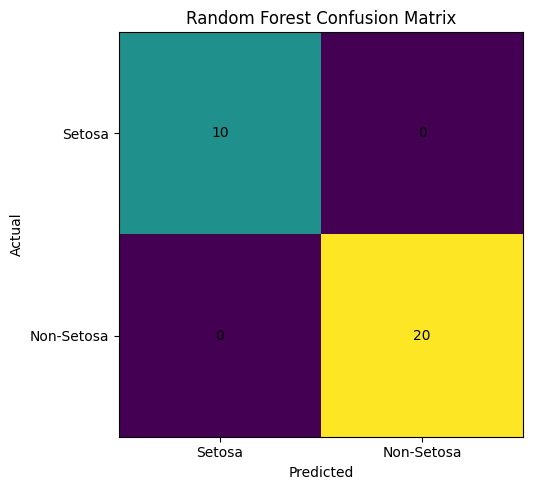

In [7]:
plt.figure(figsize=(6, 5))
plt.imshow(rf_cm)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Setosa", "Non-Setosa"])
plt.yticks([0, 1], ["Setosa", "Non-Setosa"])

for i in range(rf_cm.shape[0]):
    for j in range(rf_cm.shape[1]):
        plt.text(j, i, rf_cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


# Random Forest Feature Importance

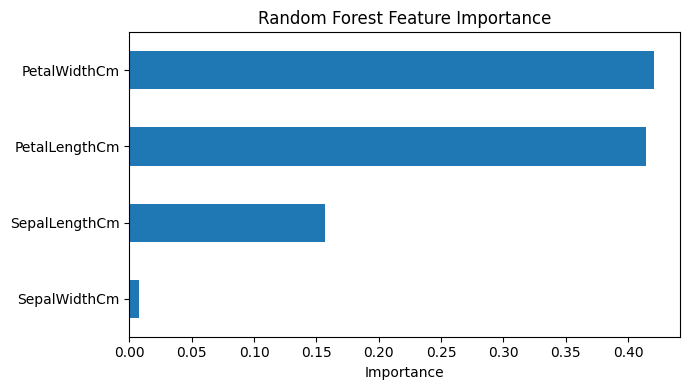

In [8]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# Decision Tree Regression

In [9]:
dtr = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

dtr.fit(X_train, y_train)
dtr_pred = dtr.predict(X_test)
dtr_class = (dtr_pred >= 0.5).astype(int)

dtr_accuracy = accuracy_score(y_test, dtr_class)
dtr_mae = mean_absolute_error(y_test, dtr_pred)
dtr_rmse = mean_squared_error(y_test, dtr_pred) ** 0.5
dtr_r2 = r2_score(y_test, dtr_pred)

print("Classification Accuracy:", round(dtr_accuracy, 4))
print("MAE:", round(dtr_mae, 4))
print("RMSE:", round(dtr_rmse, 4))
print("R2 Score:", round(dtr_r2, 4))


Classification Accuracy: 1.0
MAE: 0.0
RMSE: 0.0
R2 Score: 1.0


# Decision Tree Regression Plot

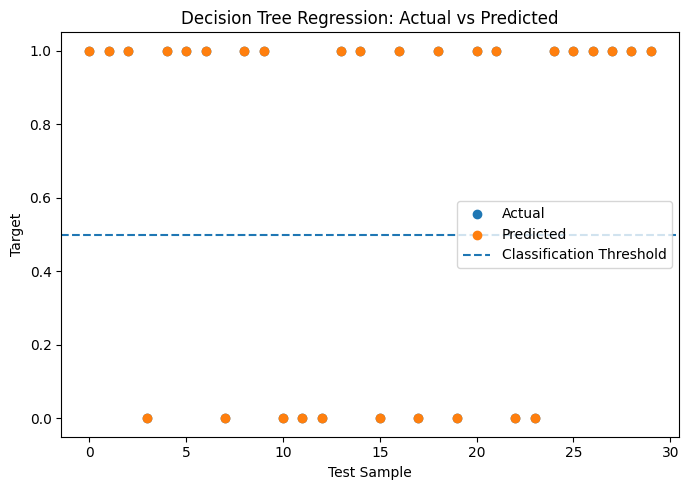

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(dtr_pred)), dtr_pred, label="Predicted")
plt.axhline(0.5, linestyle="--", label="Classification Threshold")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.xlabel("Test Sample")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()


# Support Vector Regression

In [11]:
svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1
    ))
])

svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)
svr_class = (svr_pred >= 0.5).astype(int)

svr_accuracy = accuracy_score(y_test, svr_class)
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_rmse = mean_squared_error(y_test, svr_pred) ** 0.5
svr_r2 = r2_score(y_test, svr_pred)

print("Classification Accuracy:", round(svr_accuracy, 4))
print("MAE:", round(svr_mae, 4))
print("RMSE:", round(svr_rmse, 4))
print("R2 Score:", round(svr_r2, 4))


Classification Accuracy: 1.0
MAE: 0.0537
RMSE: 0.0659
R2 Score: 0.9804


# Support Vector Regression Plot

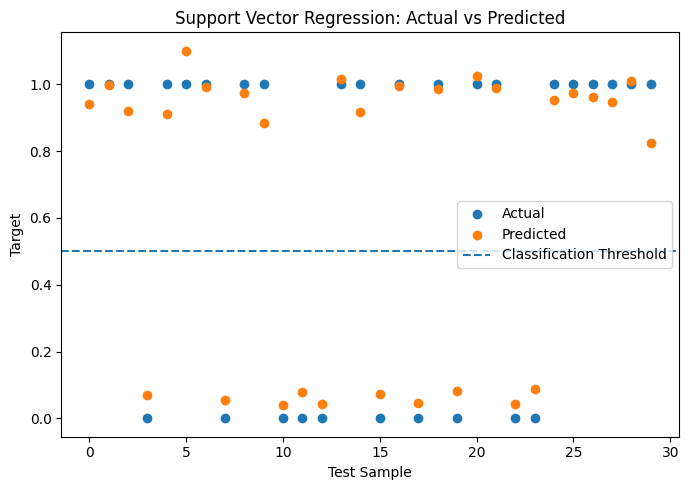

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(svr_pred)), svr_pred, label="Predicted")
plt.axhline(0.5, linestyle="--", label="Classification Threshold")
plt.title("Support Vector Regression: Actual vs Predicted")
plt.xlabel("Test Sample")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()


# Model Comparison

                      Model  Accuracy
0  Random Forest Classifier       1.0
1   Decision Tree Regressor       1.0
2  Support Vector Regressor       1.0


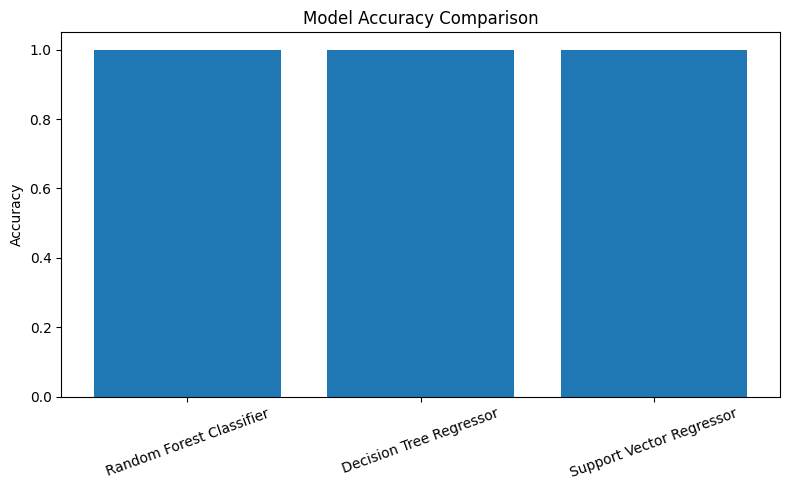

In [13]:
results = pd.DataFrame({
    "Model": [
        "Random Forest Classifier",
        "Decision Tree Regressor",
        "Support Vector Regressor"
    ],
    "Accuracy": [
        rf_accuracy,
        dtr_accuracy,
        svr_accuracy
    ]
})

print(results)

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.ylim(0, 1.05)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Sample Predictions

In [14]:
comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Random_Forest": rf_pred,
    "Decision_Tree_Regression": dtr_class,
    "SVR": svr_class
}).reset_index(drop=True)

comparison.head(15)


,Actual,Random_Forest,Decision_Tree_Regression,SVR
0,1,1,1,1
1,1,1,1,1
2,1,1,1,1
3,0,0,0,0
4,1,1,1,1
5,1,1,1,1
6,1,1,1,1
7,0,0,0,0
8,1,1,1,1
9,1,1,1,1
